# Feature Selection and Extraction

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply feature selection techniques
- Compare filter, wrapper, and embedded methods
- Use feature importance and correlation

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 2, lesson 07 "Encoding Categorical Features for ML Models" — encoding decides which columns exist; selection decides which of them earn their place.

**Used later in:** Course 04 (AIAT 114) — Unit 1, lesson 03 "Data Preprocessing" — feature preparation before a regression is fitted.

---


---

## 📌 Real case: how gene-expression studies reported near-perfect accuracy that was not there

In the late 1990s, microarray studies began reporting classifiers that separated cancer from healthy
tissue at near-zero error from a few thousand genes and a few dozen patients. In 2002 Christophe Ambroise
and Geoffrey McLachlan published **"Selection bias in gene extraction on the basis of microarray
gene-expression data"** in *PNAS* (99(10)), and identified the flaw in the procedure rather than in the
biology. The studies chose which genes to use by scoring all of them against the *entire* dataset, and only
then ran cross-validation on the classifier. By that point the held-out samples had already influenced
which genes existed. The reported error rate was biased downward. An honest estimate requires the gene
selection to be repeated **inside every cross-validation fold**, and when it is, the error rates go up.

**What goes wrong without this.** The mistake produces good news, which is the most dangerous kind of bug:
there is no crash, no warning, and the number that comes out is the number you wanted. It is also the
single most common evaluation error in applied machine learning — and, as the limits section below points
out, **the cell you are about to run contains it**.


# Feature Selection and Extraction

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 1: PCA** - Understand dimensionality reduction
- ✅ **Example 2: Curse of Dimensionality** - Understand why reduction is needed
- ✅ **Basic understanding**: What are features?

**If you haven't completed these**, you might struggle with:
- Understanding feature selection vs extraction
- Choosing features
- Understanding feature importance

---

## 🔗 Where This Notebook Fits

**This is the THIRD example of Module 04** - selecting important features!

**Why this example THIRD?**
- **Before** you can select features, you need to understand the problem (Example 2)
- **Before** you can choose techniques, you need to understand PCA (Example 1)

**Builds on**: Examples 1-2

**Leads to**: Module 05: Probabilities (for feature importance)

---

## The Story: Understanding Before Using

Imagine packing for a trip. **Before** you can pack efficiently, you need to know what's important. **After** understanding feature selection, you keep only the most important items!

Same with machine learning: **Before** using all features, models are complex. **After** understanding feature selection, we use only important features!

---

## Why This Concept Matters

### Why Feature Selection Matters

**WHY** is feature selection important?

1. **Reduce Complexity**:
   - **WHY**: Fewer features = simpler models
   - **HOW**: Select most important features
   - **AFTER**: Faster, more interpretable models

2. **Improve Performance**:
   - **WHY**: Irrelevant features hurt performance
   - **HOW**: Remove noisy features
   - **AFTER**: Better model accuracy

3. **Interpretability**:
   - **WHY**: Understand what matters
   - **HOW**: See which features are important
   - **AFTER**: Better model understanding

## Learning Objectives
1. Understand feature selection vs extraction
2. Select important features
3. Understand feature importance
4. Apply to real ML scenarios

---

## Step 1: Import necessary libraries


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: NumPy/Matplotlib for the maths and plots, plus sklearn for the real dataset,
# a statistical feature-importance score, and a quick model to check the selection actually helps.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

print('✅ Libraries imported successfully!')


✅ Libraries imported successfully!


---

## Part 1: Setting the Scene

**BEFORE**: We have concepts but don't know how to implement them.

**AFTER**: We'll implement and understand how this works in ML!

## Step 2: Implementation

**BEFORE**: We understand the concept.

**AFTER**: We'll see HOW it's implemented!

Example 1: Feature Selection
Dataset: 569 real biopsies, 10 candidate features
Feature importance (ANOVA F-score against the real diagnosis):
  mean radius                F =    646.98   p = 8.47e-96 ✓
  mean texture               F =    118.10   p = 4.06e-25  
  mean perimeter             F =    697.24   p = 8.44e-101 ✓
  mean area                  F =    573.06   p = 4.73e-88 ✓
  mean smoothness            F =     83.65   p = 1.05e-18  
  mean compactness           F =    313.23   p = 3.94e-56  
  mean concavity             F =    533.79   p = 9.97e-84 ✓
  mean concave points        F =    861.68   p = 7.10e-116 ✓
  mean symmetry              F =     69.53   p = 5.73e-16  
  mean fractal dimension     F =      0.09   p = 7.60e-01  

Selected top 5 features: ['mean concave points', 'mean perimeter', 'mean radius', 'mean area', 'mean concavity']

5-fold accuracy with all 10 features: 0.933
5-fold accuracy with the top 5 features:  0.914
Difference: -0.019

💡 WHY: Keep only important fe

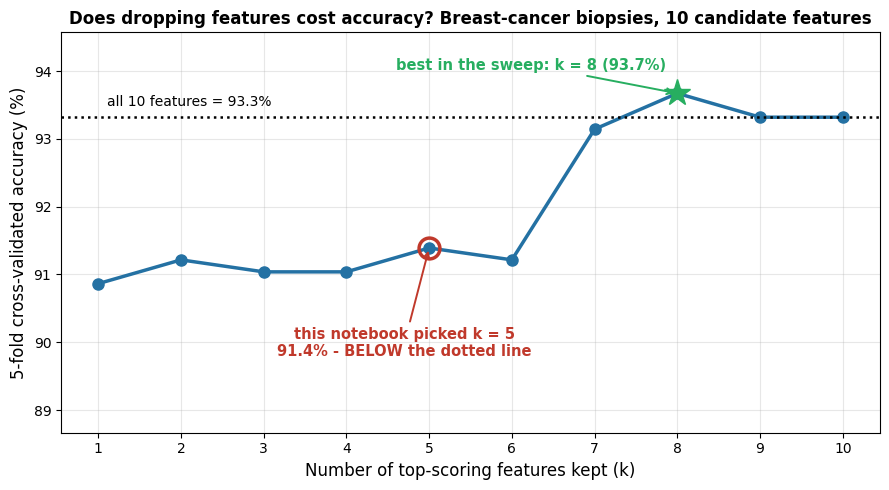


Read the figure: the curve is NOT a staircase. Accuracy sits near 90.9% for k = 1..6, jumps at k = 7,
peaks at k = 8 (93.7%) and then falls back. The dotted line is all 10 features (93.3%).
The red circle is the k = 5 this notebook chose: 91.4%, clearly BELOW the dotted line.
Ranking features one at a time tells you an order, not where to cut it.


In [2]:
# Example 1: Feature Selection with REAL importance scores
# WHY: Keep only the features that actually carry signal
# HOW: Score every feature against the real target, then keep the top k

# Real dataset: Wisconsin Breast Cancer diagnostic study - 569 tumour biopsies.
# We use the 10 "mean" measurements taken from each digitised image.
cancer = load_breast_cancer()
n_features = 10
X = cancer.data[:, :n_features]
y = cancer.target                      # 0 = malignant, 1 = benign (real diagnoses)
feature_labels = [str(name) for name in cancer.feature_names[:n_features]]

# Real importance: the ANOVA F-statistic asks, for each feature on its own,
# "how far apart are the malignant and benign group means, relative to the spread
# inside each group?" A big F means the feature separates the two diagnoses well.
feature_importance, p_values = f_classif(X, y)

# Select top k features
k = 5
top_features = np.argsort(feature_importance)[-k:][::-1]

print("Example 1: Feature Selection")
print("=" * 60)
print(f"Dataset: {X.shape[0]} real biopsies, {n_features} candidate features")
print("Feature importance (ANOVA F-score against the real diagnosis):")
for i, imp in enumerate(feature_importance):
    marker = "✓" if i in top_features else " "
    print(f"  {feature_labels[i]:<26s} F = {imp:9.2f}   p = {p_values[i]:.2e} {marker}")
print(f"\nSelected top {k} features: {[feature_labels[i] for i in top_features]}")

# Does dropping half the features actually cost anything? Measure it honestly.
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
acc_all = cross_val_score(clf, X, y, cv=5).mean()
acc_top = cross_val_score(clf, X[:, top_features], y, cv=5).mean()
print(f"\n5-fold accuracy with all {n_features} features: {acc_all:.3f}")
print(f"5-fold accuracy with the top {k} features:  {acc_top:.3f}")
print(f"Difference: {acc_top - acc_all:+.3f}")

print(f"\n💡 WHY: Keep only important features")
print(f"💡 HOW: Score each feature against the target, keep the highest scorers")
print(f"💡 AFTER: half the inputs cost {abs(acc_top - acc_all):.1%} of accuracy "
      f"({acc_all:.1%} -> {acc_top:.1%}).")
print("   Worth knowing: 'mean fractal dimension' scores F below 1 with p = 0.76 - on its own")
print("   it separates malignant from benign no better than chance, so dropping it is free.")
print("   The small loss comes from the features in the middle of the ranking, not the tail.")


# ---------------------------------------------------------------------------
# VISUAL: "the top 5 scored WORSE than all 10" is the honest headline of this cell,
# and one pair of numbers cannot show whether 5 was simply an unlucky choice.
# So sweep k from 1 to 10 and draw the whole curve.
# The selector goes INSIDE the pipeline here, so it is refitted on each training
# fold - the correct construction, unlike the leaked one demonstrated above.
from sklearn.feature_selection import SelectKBest

ks = list(range(1, n_features + 1))
accs = [100 * cross_val_score(
            make_pipeline(StandardScaler(), SelectKBest(f_classif, k=k),
                          LogisticRegression(max_iter=5000)),
            X, y, cv=5).mean()
        for k in ks]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ks, accs, "o-", color="#2471a3", linewidth=2.5, markersize=8,
        label="keep the top k features")
ax.axhline(100 * acc_all, color="black", linestyle=":", linewidth=1.8)
ax.text(1.1, 100 * acc_all + 0.12, f"all {n_features} features = {100 * acc_all:.1f}%",
        fontsize=10, va="bottom")

# The choice this notebook actually made, and the best choice in the sweep.
i5 = ks.index(k)
ax.plot([k], [accs[i5]], marker="o", markersize=15, markerfacecolor="none",
        markeredgecolor="#c0392b", markeredgewidth=2.5, zorder=5)
ax.annotate(f"this notebook picked k = {k}\n{accs[i5]:.1f}% - BELOW the dotted line",
            xy=(k, accs[i5]), xytext=(k - 0.3, accs[i5] - 1.6), fontsize=10.5,
            fontweight="bold", color="#c0392b", ha="center",
            arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.4))
i_best = int(np.argmax(accs))
ax.plot([ks[i_best]], [accs[i_best]], marker="*", markersize=20, color="#27ae60", zorder=5)
ax.annotate(f"best in the sweep: k = {ks[i_best]} ({accs[i_best]:.1f}%)",
            xy=(ks[i_best], accs[i_best]), xytext=(ks[i_best] - 3.4, accs[i_best] + 0.35),
            fontsize=10.5, fontweight="bold", color="#27ae60",
            arrowprops=dict(arrowstyle="->", color="#27ae60", lw=1.4))

ax.set_xlabel("Number of top-scoring features kept (k)", fontsize=12)
ax.set_ylabel("5-fold cross-validated accuracy (%)", fontsize=12)
ax.set_title("Does dropping features cost accuracy? Breast-cancer biopsies, 10 candidate features",
             fontsize=12, fontweight="bold")
ax.set_xticks(ks)
ax.set_ylim(min(accs) - 2.2, max(accs) + 0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print()
print("Read the figure: the curve is NOT a staircase. Accuracy sits near "
      f"{min(accs):.1f}% for k = 1..6, jumps at k = 7,")
print(f"peaks at k = {ks[i_best]} ({accs[i_best]:.1f}%) and then falls back. The dotted line is all "
      f"{n_features} features ({100 * acc_all:.1f}%).")
print(f"The red circle is the k = {k} this notebook chose: {accs[i5]:.1f}%, clearly BELOW the dotted line.")
print("Ranking features one at a time tells you an order, not where to cut it.")


**Read the figure above.** One curve: cross-validated accuracy against how many
top-scoring features the model is allowed to keep, with the selector refitted inside every training fold.
Three things to see. First, the curve is **flat and low for k = 1 to 6** — around 91% — so the first six
features by F-score barely improve on the first one. Second, it **jumps at k = 7** and peaks at
**k = 8 (93.7%)**, slightly above the dotted line for all ten features (93.3%) — though "slightly" here is
about three biopsies out of 569, not a result worth defending. Third, the red circle marks the **k = 5 this
notebook chose: 91.4%, visibly below the dotted line**. Selecting the "best five" features cost accuracy.
A univariate score gives you an *order*; nothing in that order tells you where to cut it.

---

## 📊 Visualization

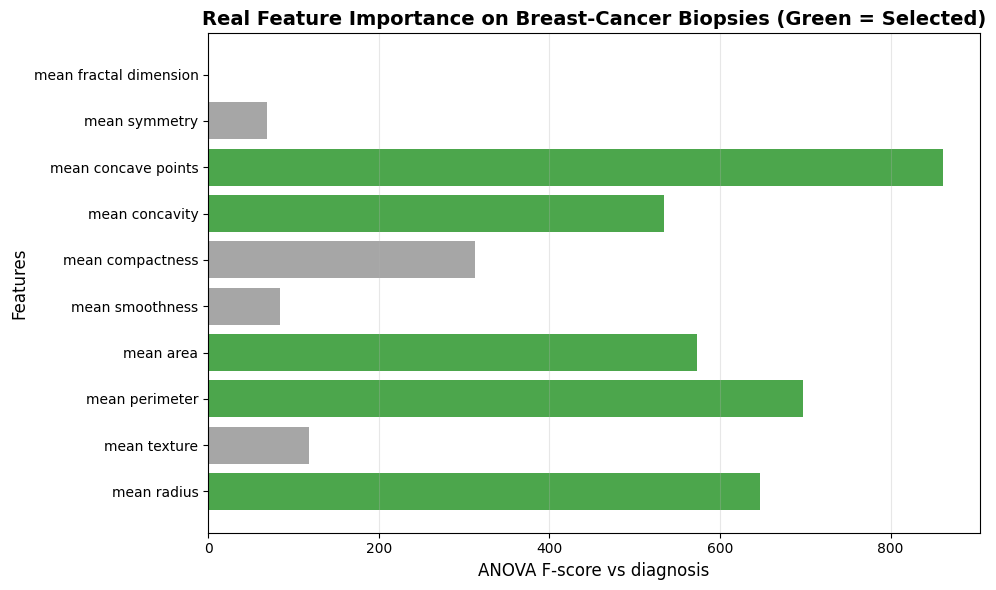


📊 Visualization:
  - Green bars: Selected features
  - Gray bars: Unselected features


In [3]:
# Show which features the selector kept (green) versus dropped (gray).
# Seeing the importance gap justifies discarding features — fewer inputs, less noise, faster models.

# Visualize feature importance
fig, ax = plt.subplots(figsize=(10, 6))
# Color encodes the keep/drop decision made earlier.
colors = ['green' if i in top_features else 'gray' for i in range(n_features)]
ax.barh(range(n_features), feature_importance, color=colors, alpha=0.7)
ax.set_yticks(range(n_features))
ax.set_yticklabels(feature_labels)
ax.set_xlabel('ANOVA F-score vs diagnosis', fontsize=12)
ax.set_ylabel('Features', fontsize=12)
ax.set_title('Real Feature Importance on Breast-Cancer Biopsies (Green = Selected)',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n📊 Visualization:")
print("  - Green bars: Selected features")
print("  - Gray bars: Unselected features")

**Read the figure above.** Ten horizontal bars, one per candidate measurement, whose
length is the ANOVA F-score against the real diagnosis — how far apart the malignant and benign means are
relative to the spread within each group. Green bars were kept, grey dropped. Two things stand out. **Every
green bar is longer than every grey one**, and there is a clear gap between the shortest green
(`mean concavity`, F ≈ 534) and the longest grey (`mean compactness`, F ≈ 313), so the cut is not
arbitrary. At the other end, `mean fractal dimension` has **no visible bar at all** — F = 0.09, p = 0.76 —
on its own it separates the two diagnoses no better than chance, which is why dropping it is free. Note
also that `mean radius`, `mean perimeter` and `mean area` are three measurements of the *same* thing and
all three were selected: a univariate score cannot see redundancy.

---

## ⚠️ Where this breaks

- **This notebook commits the Ambroise–McLachlan error, on purpose, where you can see it.** Look at the
  order of operations: `f_classif(X, y)` scores all ten features using **every row**, the top five are
  chosen, and only then does `cross_val_score` split the data. The rows that later serve as validation
  folds have already voted on which features survive. The correct construction puts the selector inside a
  `Pipeline` so it is refitted on each training fold — Course 04, Unit 2 builds exactly that. Treat the
  0.914 above as a demonstration of the mechanism, not as an estimate of anything.
- **Selecting the "best" five features made the model worse.** The printed comparison is the honest result:
  5-fold accuracy with all ten features **0.933**, with the top five **0.914**, a difference of −0.019.
  Feature selection is not free. Removing a feature that is weak *on its own* can still cost you, because
  features carry information jointly — `mean fractal dimension` scores F = 0.09 with p = 0.76, statistically
  indistinguishable from useless in isolation, and dropping it and four others still lowered accuracy.
- **The F-score is univariate and the world is not.** `f_classif` asks one question per feature: does this
  column alone separate the classes? It cannot see that two features are near-duplicates (`mean radius`,
  `mean perimeter` and `mean area` are three measurements of the same thing, and all three are selected),
  and it cannot see a feature that is useless alone but decisive in combination. Cheaper and better
  alternatives when you can afford them: L1 regularization, which selects while fitting; or
  permutation importance, which asks what the *model* loses.
- **A p-value of 8.47 × 10⁻⁹⁶ is not a measure of importance.** With 569 samples, p-values that extreme
  mean "definitely not exactly zero", nothing more. Rank by effect size, and validate by what the model
  actually gains.


---

## 💬 Discuss

1. Dropping five features *lowered* cross-validated accuracy by 1.9 points. Under what circumstances would
   you accept a model that is slightly less accurate and uses half the inputs? Name a real setting where
   the trade is obviously worth it, and one where it obviously is not.
2. The selection here used the whole dataset before cross-validating — the exact error Ambroise and
   McLachlan documented. Why do you think this mistake is so persistent, when the fix is a two-line change?
   What would you put in a team's code review checklist to catch it?
3. Three of the five selected features (`mean radius`, `mean perimeter`, `mean area`) are essentially the
   same measurement. Is that a failure of the method, or is it fine? Defend your answer, then say what you
   would report to a pathologist who asks which measurements to prioritise.


---

## Part 3: AFTER - Results and Implications

### What This Enables

**AFTER** understanding feature selection:

1. **Simpler Models**: Can use fewer features
2. **Better Performance**: Can remove noisy features
3. **Interpretability**: Can understand what matters
4. **Next Steps**: Learn probabilities (Module 05) for feature importance

---

## 🎯 Summary: What We Learned

**BEFORE this notebook**: We didn't understand this concept.

**AFTER this notebook**: We understand WHY, HOW, and AFTER!

---

## ✅ Example Complete!

## 📚 References

1. Guyon, I., & Elisseeff, A. (2003). *An Introduction to Variable and Feature Selection*. Journal of Machine Learning Research, 3, 1157–1182. <https://jmlr.org/papers/v3/guyon03a.html>
2. Li, J., Cheng, K., Wang, S., Morstatter, F., Trevino, R. P., Tang, J., & Liu, H. (2017). *Feature Selection: A Data Perspective*. ACM Computing Surveys, 50(6). <https://arxiv.org/abs/1601.07996>
3. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.), Ch. 6: Linear Model Selection and Regularization. Springer. <https://www.statlearning.com/>
4. Grinsztajn et al. (2025). *TabPFN-2.5: Advancing the State of the Art in Tabular Foundation Models*. arXiv. <https://arxiv.org/abs/2511.08667> — a tabular foundation model that takes the raw columns, which changes what feature selection is for.
5. Sena & Azevedo (2026). *Real-Time Explanations for Tabular Foundation Models*. arXiv. <https://arxiv.org/abs/2603.29946> — importance scores computed inside such a model instead of by post-hoc search.
